# 1 · Análisis Exploratorio — MTG-Jamendo (Mood/Theme)

**TFG:** Reconocimiento de Emociones Musicales (Fine-Tuning vs Zero-Shot)  
**Dataset:** MTG-Jamendo — subset `autotagging_moodtheme.tsv`  
**Tarea:** Emotion and Theme Recognition (MediaEval)

---

## 0 · Imports y Configuración

In [29]:
import sys, os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import requests
from pathlib import Path
from tqdm.notebook import tqdm

# Estilo visual
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150

# Rutas del proyecto
PROJECT_ROOT = Path(os.path.abspath('')).parent
DATA_DIR     = PROJECT_ROOT / 'data'
FIGURES_DIR  = PROJECT_ROOT / 'figures'
TSV_PATH     = PROJECT_ROOT / 'mtg-jamendo-dataset' / 'data' / 'autotagging_moodtheme.tsv'

# Añadir src/ al path para importar audio_utils
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

print(f'Proyecto: {PROJECT_ROOT}')
print(f'TSV:      {TSV_PATH}')
print(f'Existe:   {TSV_PATH.exists()}')

Proyecto: c:\Users\Usuario\OneDrive - UNIVERSIDAD DE MURCIA\Escritorio\CIENCIA DE DATOS RUBEN\CUARTO\TFG_Emociones
TSV:      c:\Users\Usuario\OneDrive - UNIVERSIDAD DE MURCIA\Escritorio\CIENCIA DE DATOS RUBEN\CUARTO\TFG_Emociones\mtg-jamendo-dataset\data\autotagging_moodtheme.tsv
Existe:   True


---
## 1 · Carga del Dataset

In [30]:
# ── Parsear el TSV (formato especial: tags separados por tabs extra) ──
records = []
with open(TSV_PATH, encoding='utf-8') as f:
    header = f.readline()  # TRACK_ID  ARTIST_ID  ALBUM_ID  PATH  DURATION  TAGS...
    for line in f:
        parts = line.strip().split('\t')
        track_id  = parts[0]
        artist_id = parts[1]
        album_id  = parts[2]
        path      = parts[3]
        duration  = float(parts[4])
        tags      = [t.replace('mood/theme---', '') for t in parts[5:] if t.startswith('mood/theme---')]
        records.append({
            'track_id':  track_id,
            'artist_id': artist_id,
            'album_id':  album_id,
            'path':      path,
            'duration':  duration,
            'tags':      tags,
            'n_tags':    len(tags),
        })

df = pd.DataFrame(records)

# ── Estadísticas básicas ──
all_tags     = [tag for tags in df['tags'] for tag in tags]
unique_tags  = sorted(set(all_tags))
n_tracks     = len(df)
n_tags       = len(unique_tags)

print('=' * 55)
print('  MTG-Jamendo — Subset mood/theme')
print('=' * 55)
print(f'  Tracks totales:         {n_tracks:>7,}')
print(f'  Etiquetas únicas:       {n_tags:>7}')
print(f'  Anotaciones totales:    {len(all_tags):>7,}')
print(f'  Media tags/canción:     {len(all_tags)/n_tracks:>7.2f}')
print(f'  Duración media (s):     {df["duration"].mean():>7.1f}')
print('=' * 55)

df.head()

  MTG-Jamendo — Subset mood/theme
  Tracks totales:          18,486
  Etiquetas únicas:            59
  Anotaciones totales:     32,527
  Media tags/canción:        1.76
  Duración media (s):       219.4


,track_id,artist_id,album_id,path,duration,tags,n_tags
0,track_0000948,artist_000087,album_000149,48/948.mp3,212.7,[background],1
1,track_0000950,artist_000087,album_000149,50/950.mp3,248.0,[background],1
2,track_0000951,artist_000087,album_000149,51/951.mp3,199.7,[background],1
3,track_0002165,artist_000326,album_000347,65/2165.mp3,229.0,[film],1
4,track_0002263,artist_000320,album_000366,63/2263.mp3,494.7,[melancholic],1


---
## 2 · Distribución de Etiquetas (Long-Tail)

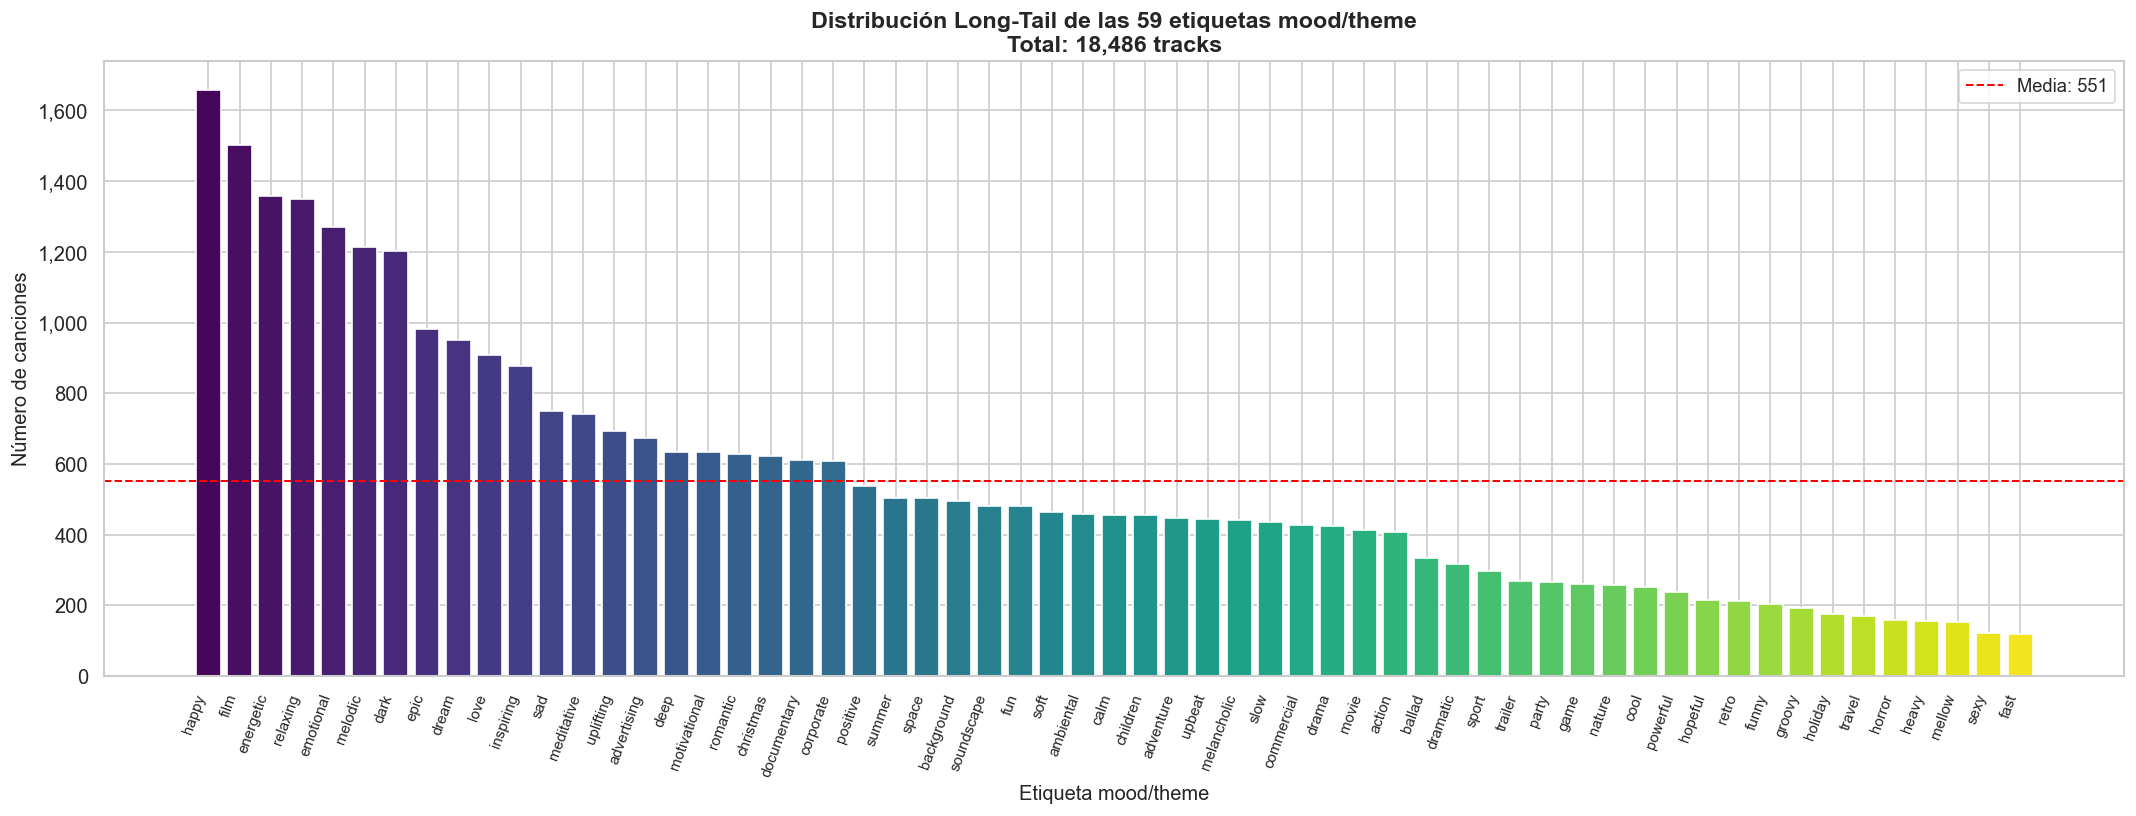


Desbalanceo max/min: 1657 / 119 = 13.9x
Top 5: [('happy', 1657), ('film', 1502), ('energetic', 1357), ('relaxing', 1350), ('emotional', 1271)]
Bottom 5: [('horror', 158), ('heavy', 156), ('mellow', 154), ('sexy', 122), ('fast', 119)]


In [31]:
# ── Conteo por etiqueta ──
tag_counts = pd.Series(all_tags).value_counts()

# ── Gráfico de barras verticales (59 etiquetas → long tail) ──
fig, ax = plt.subplots(figsize=(18, 7))

palette = sns.color_palette('viridis', n_colors=len(tag_counts))
bars = ax.bar(range(len(tag_counts)), tag_counts.values, color=palette)

ax.set_xticks(range(len(tag_counts)))
ax.set_xticklabels(tag_counts.index, rotation=70, ha='right', fontsize=9)
ax.set_ylabel('Número de canciones', fontsize=12)
ax.set_xlabel('Etiqueta mood/theme', fontsize=12)
ax.set_title(
    f'Distribución Long-Tail de las {n_tags} etiquetas mood/theme\n'
    f'Total: {n_tracks:,} tracks',
    fontsize=14, fontweight='bold'
)

# Línea de media
mean_count = tag_counts.mean()
ax.axhline(mean_count, color='red', linestyle='--', linewidth=1.2, label=f'Media: {mean_count:.0f}')
ax.legend(fontsize=11)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'distribucion_longtail.png', bbox_inches='tight')
plt.show()

# ── Ratio desbalanceo ──
print(f'\nDesbalanceo max/min: {tag_counts.max()} / {tag_counts.min()} = {tag_counts.max()/tag_counts.min():.1f}x')
print(f'Top 5: {list(tag_counts.head(5).items())}')
print(f'Bottom 5: {list(tag_counts.tail(5).items())}')

---
## 3 · Distribución de Duración de los Tracks

Analizamos si los tracks son mayoritariamente más largos o más cortos que 30 s  
(para justificar si el preprocesador necesita más **padding** o más **crop**).

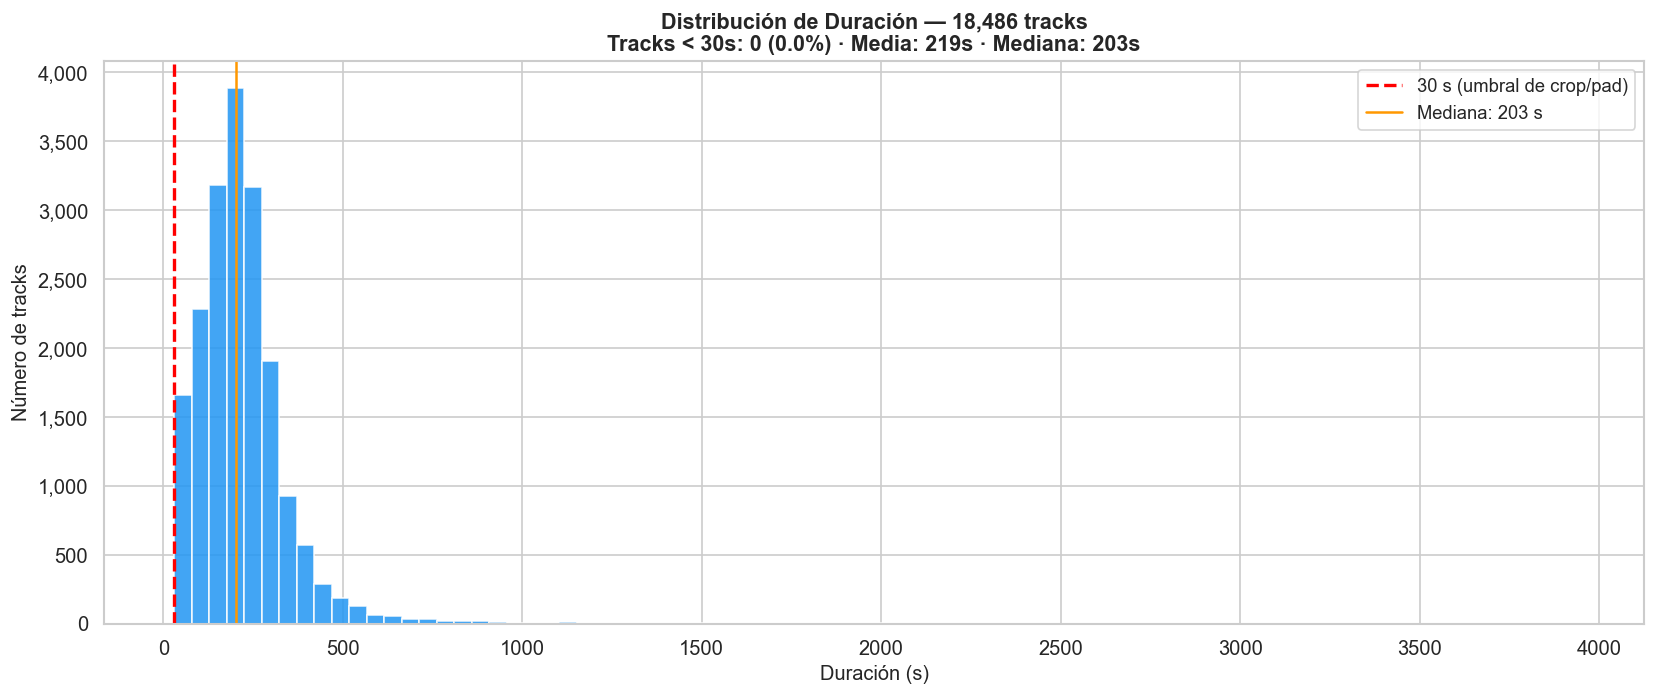

Tracks < 30 s:      0 (0.0%) → necesitan PADDING
Tracks >= 30 s: 18486 (100.0%) → serán RECORTADOS

Conclusión: La gran mayoría requiere CROP


In [32]:
# ── Histograma de duración ──
fig, ax = plt.subplots(figsize=(14, 6))

ax.hist(df['duration'], bins=80, color='#2196F3', edgecolor='white', alpha=0.85)

# Línea vertical roja en 30 s
ax.axvline(30, color='red', linestyle='--', linewidth=2,
           label=f'30 s (umbral de crop/pad)')

# Estadísticas
below_30 = (df['duration'] < 30).sum()
pct_below = 100 * below_30 / n_tracks
median_dur = df['duration'].median()

ax.axvline(median_dur, color='#FF9800', linestyle='-', linewidth=1.5,
           label=f'Mediana: {median_dur:.0f} s')

ax.set_xlabel('Duración (s)', fontsize=12)
ax.set_ylabel('Número de tracks', fontsize=12)
ax.set_title(
    f'Distribución de Duración — {n_tracks:,} tracks\n'
    f'Tracks < 30s: {below_30} ({pct_below:.1f}%) · Media: {df["duration"].mean():.0f}s · Mediana: {median_dur:.0f}s',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'distribucion_duracion.png', bbox_inches='tight')
plt.show()

# ── Resumen ──
print(f'Tracks < 30 s:  {below_30:>5} ({pct_below:.1f}%) → necesitan PADDING')
print(f'Tracks >= 30 s: {n_tracks - below_30:>5} ({100-pct_below:.1f}%) → serán RECORTADOS')
print(f'\nConclusión: {"La gran mayoría requiere CROP" if pct_below < 10 else "Hay un porcentaje significativo que requiere PADDING"}')

---
## 4 · Clustermap de Correlación de Etiquetas

Usamos `sns.clustermap` con clustering jerárquico (Ward) para identificar  
bloques de etiquetas redundantes o semánticamente relacionadas.

Matriz binaria: (18486, 59)  (tracks × tags)


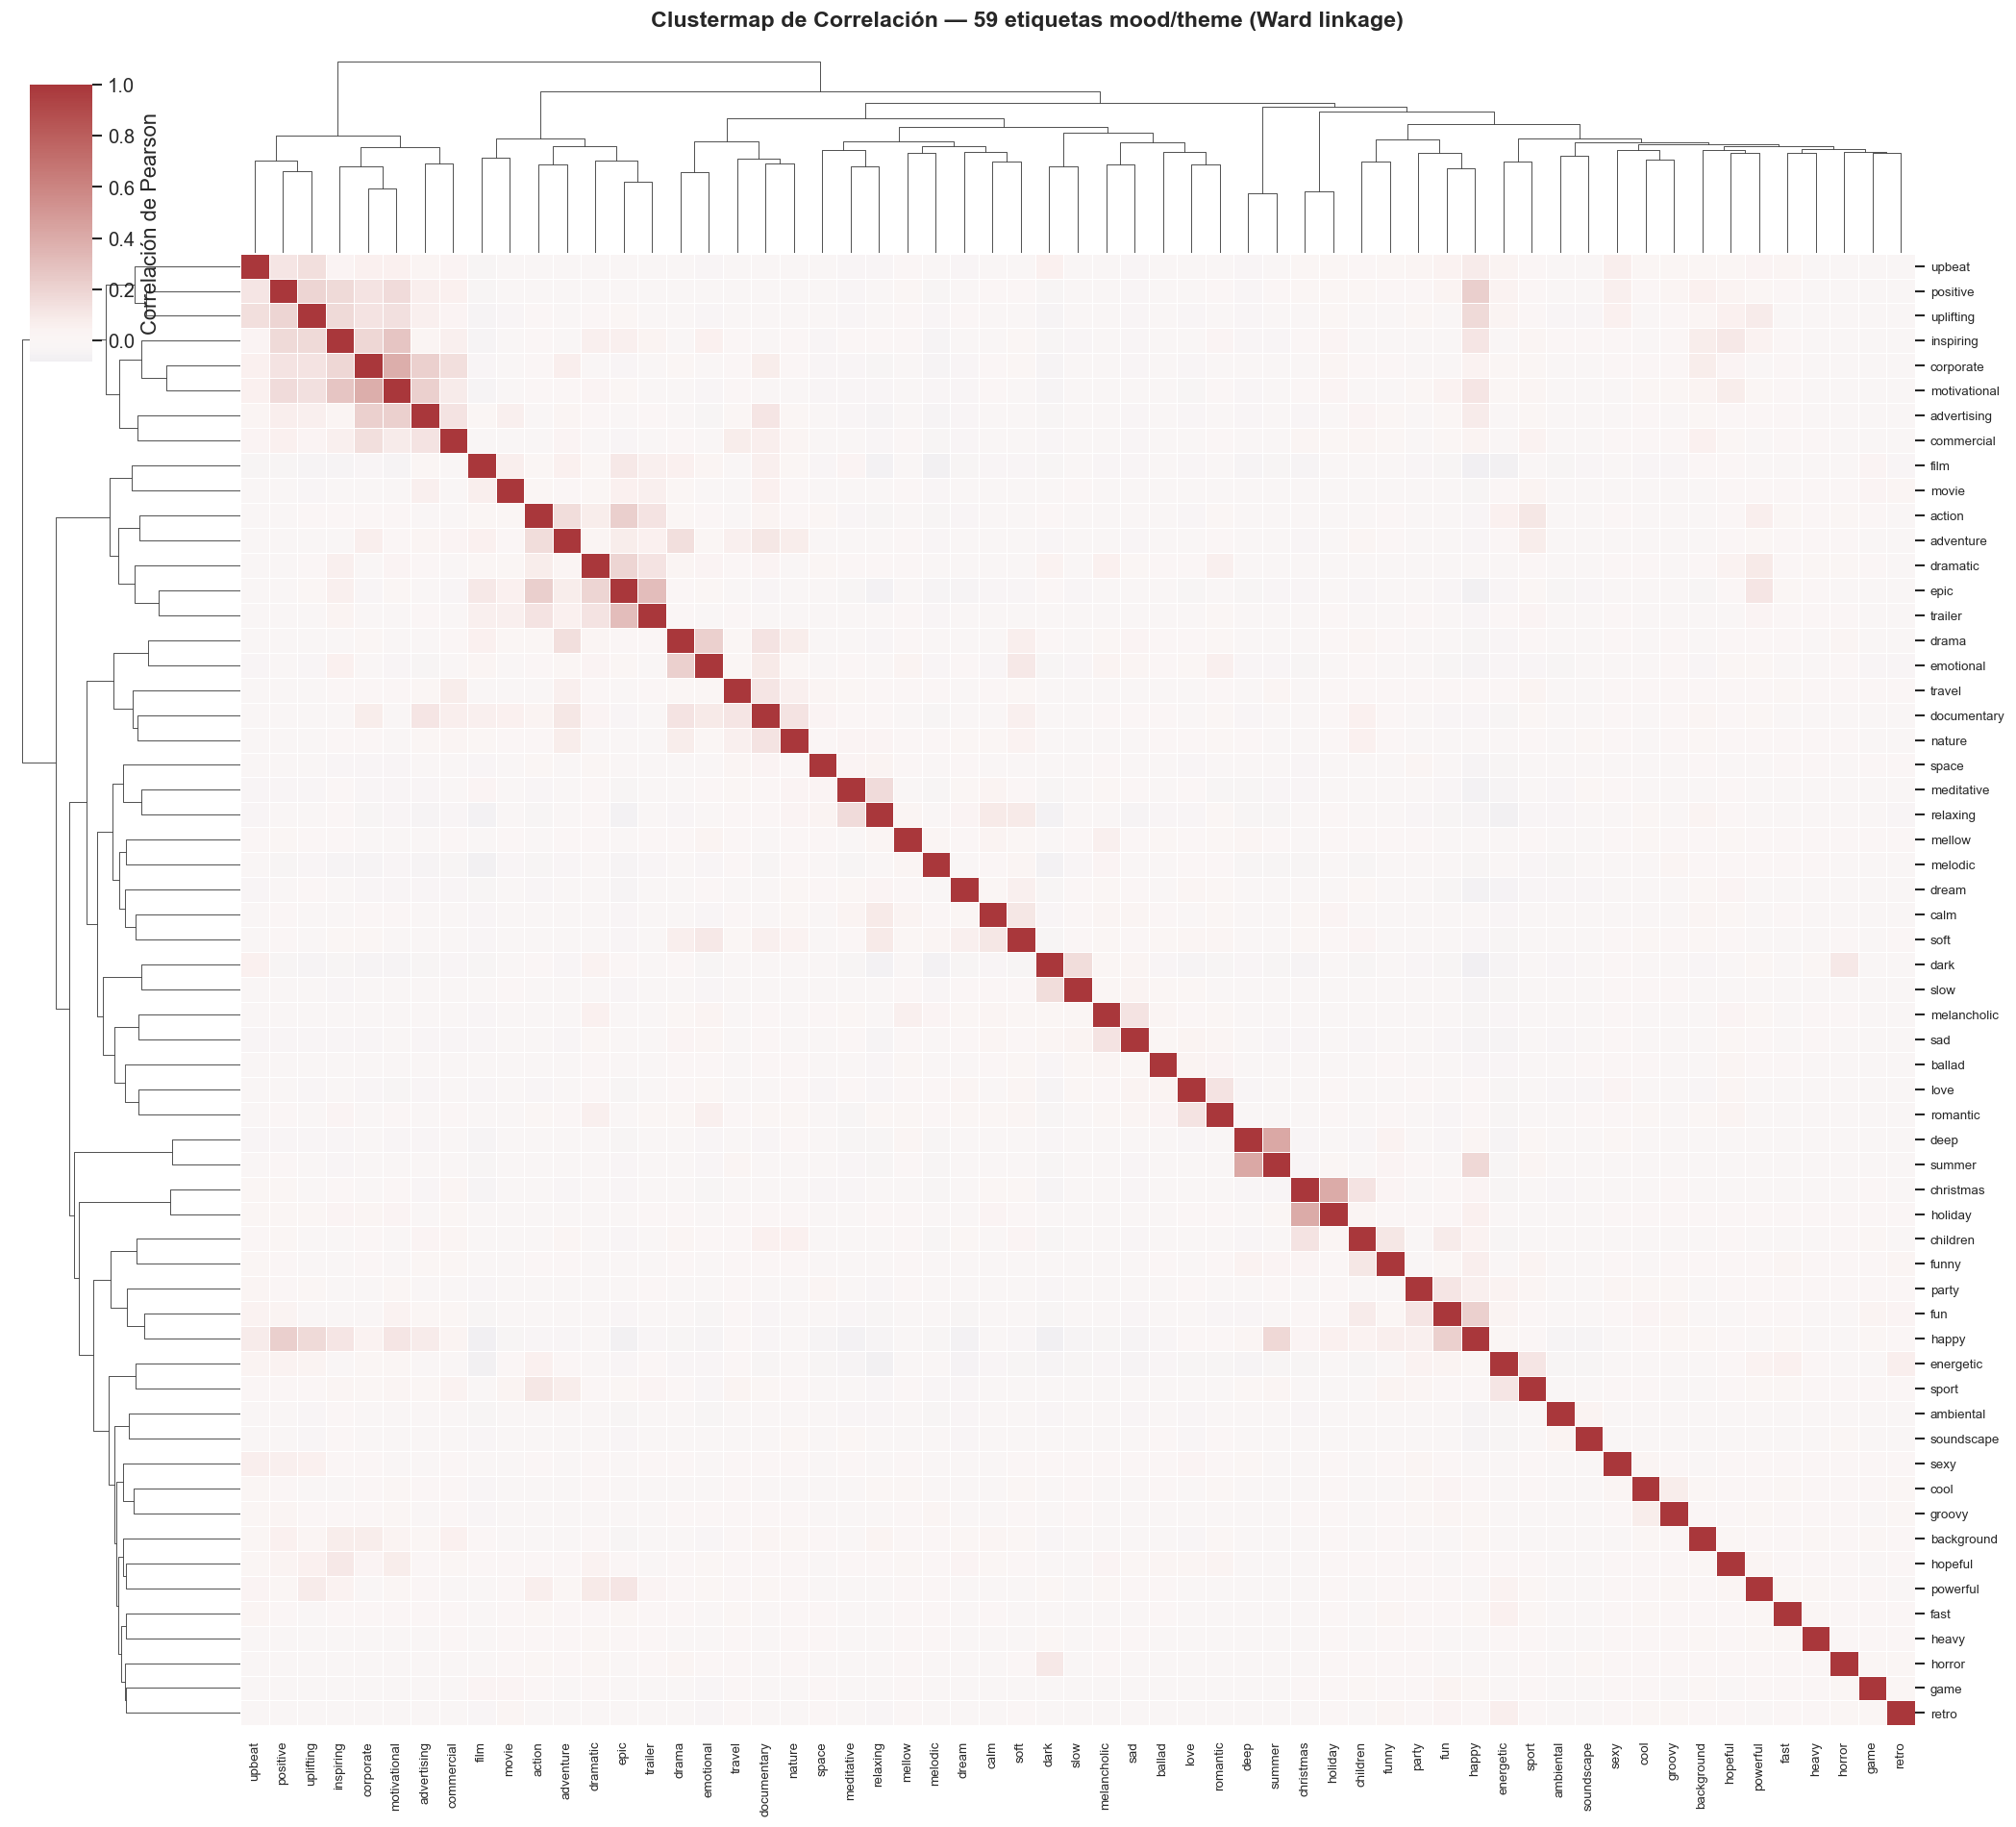

✅ Clustermap guardado en figures/clustermap_correlacion.png


In [ ]:
# ── Construir la matriz binaria (tracks × tags) ──
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer(classes=unique_tags)
tag_matrix = mlb.fit_transform(df['tags'])
tag_df = pd.DataFrame(tag_matrix, columns=unique_tags)

print(f'Matriz binaria: {tag_df.shape}  (tracks × tags)')

# ── Matriz de correlación (Pearson) ──
corr_matrix = tag_df.corr()

# ── Clustermap con clustering jerárquico Ward ──
g = sns.clustermap(
    corr_matrix,
    method='ward',
    cmap='vlag',
    center=0,
    linewidths=0.3,
    linecolor='white',
    figsize=(18, 16),
    dendrogram_ratio=(0.12, 0.12),
    cbar_pos=(0.02, 0.82, 0.03, 0.15),
    cbar_kws={'label': 'Correlación de Pearson'},
    xticklabels=True,
    yticklabels=True,
)
g.ax_heatmap.tick_params(axis='both', labelsize=8)
g.fig.suptitle(
    'Clustermap de Correlación — 59 etiquetas mood/theme (Ward linkage)',
    fontsize=14, fontweight='bold', y=1.01
)
g.savefig(FIGURES_DIR / 'clustermap_correlacion.png', bbox_inches='tight', dpi=150)
plt.show()

print('Clustermap guardado en figures/clustermap_correlacion.png')

In [ ]:
# ── Top 10 Parejas Redundantes (mayor correlación positiva) ──
import itertools

pairs = []
for i, j in itertools.combinations(range(len(unique_tags)), 2):
    pairs.append({
        'Tag A': unique_tags[i],
        'Tag B': unique_tags[j],
        'Correlación': corr_matrix.iloc[i, j],
    })

pairs_df = pd.DataFrame(pairs).sort_values('Correlación', ascending=False)

print('=' * 60)
print('  TOP 10 PAREJAS REDUNDANTES (mayor correlación positiva)')
print('=' * 60)

top10 = pairs_df.head(10).reset_index(drop=True)
top10.index = top10.index + 1  # 1-indexed
top10['Correlación'] = top10['Correlación'].apply(lambda x: f'{x:.3f}')
print(top10.to_string())

# ── Todas las parejas con correlación > 0.3 ──
high_corr = pairs_df[pairs_df['Correlación'] > 0.3]
print(f'\n{len(high_corr)} parejas con correlación > 0.3')
print(f'    (Potencial redundancia → considerar fusionar o eliminar en preproceso)')

# ── También las parejas con mayor correlación NEGATIVA ──
print(f'\n── Top 5 parejas con mayor correlación NEGATIVA (opuestas) ──')
bottom5 = pairs_df.tail(5).reset_index(drop=True)
bottom5.index = bottom5.index + 1
bottom5['Correlación'] = bottom5['Correlación'].apply(lambda x: f'{x:.3f}')
print(bottom5.to_string())

  TOP 10 PAREJAS REDUNDANTES (mayor correlación positiva)
          Tag A         Tag B Correlación
1          deep        summer       0.420
2     christmas       holiday       0.405
3     corporate  motivational       0.383
4          epic       trailer       0.309
5     inspiring  motivational       0.271
6         happy      positive       0.225
7        action          epic       0.223
8           fun         happy       0.220
9   advertising     corporate       0.215
10        drama     emotional       0.214

⚠️  4 parejas con correlación > 0.3
    (Potencial redundancia → considerar fusionar o eliminar en preproceso)

── Top 5 parejas con mayor correlación NEGATIVA (opuestas) ──
       Tag A     Tag B Correlación
1       film   melodic      -0.070
2  energetic      film      -0.070
3  energetic  relaxing      -0.072
4       dark     happy      -0.077
5       film     happy      -0.084


---
## 5 · Artist Bias (Crítico)

Algunas etiquetas pueden estar dominadas por un solo artista, lo que introduce sesgo.  
Calculamos el **Top Artist Share (%)** para cada etiqueta.

In [ ]:
# ── Explode tags → una fila por (track, tag) ──
df_exploded = df.explode('tags')

# ── Para cada tag, contar tracks por artista ──
bias_records = []
for tag in unique_tags:
    tag_data = df_exploded[df_exploded['tags'] == tag]
    total_tracks = len(tag_data)
    artist_counts = tag_data['artist_id'].value_counts()
    top_artist = artist_counts.index[0]
    top_artist_count = artist_counts.iloc[0]
    n_artists = len(artist_counts)
    bias_records.append({
        'Etiqueta':          tag,
        'Total Tracks':      total_tracks,
        'Nº Artistas':       n_artists,
        'Top Artista':       top_artist,
        'Tracks Top Artista': top_artist_count,
        'Top Artist Share %': round(100 * top_artist_count / total_tracks, 1),
    })

bias_df = pd.DataFrame(bias_records).sort_values('Top Artist Share %', ascending=False)

print(f'\n{"=" * 75}')
print('  ARTIST BIAS — Etiquetas ordenadas por dominancia del artista principal')
print(f'{"=" * 75}')

# ── Resaltar etiquetas con más del 30% de sesgo ──
high_bias = bias_df[bias_df['Top Artist Share %'] >= 30]
if len(high_bias) > 0:
    print(f'\n{len(high_bias)} etiquetas con Top Artist Share ≥ 30%:')
    print(high_bias[['Etiqueta', 'Total Tracks', 'Nº Artistas', 'Top Artista', 'Top Artist Share %']].to_string(index=False))

bias_df


  ARTIST BIAS — Etiquetas ordenadas por dominancia del artista principal

⚠️  3 etiquetas con Top Artist Share ≥ 30%:
  Etiqueta  Total Tracks  Nº Artistas   Top Artista  Top Artist Share %
      slow           437          103 artist_471813                42.6
 ambiental           460           64 artist_338660                37.2
soundscape           480           81 artist_337741                30.2


,Etiqueta,Total Tracks,Nº Artistas,Top Artista,Tracks Top Artista,Top Artist Share %
49,slow,437,103,artist_471813,186,42.6
3,ambiental,460,64,artist_338660,171,37.2
51,soundscape,480,81,artist_337741,145,30.2
45,retro,213,54,artist_357317,57,26.8
9,commercial,428,62,artist_007063,93,21.7
0,action,407,73,artist_000560,86,21.1
57,upbeat,444,88,artist_359034,93,20.9
7,children,456,85,artist_490314,95,20.8
54,summer,505,77,artist_490858,102,20.2
58,uplifting,693,112,artist_437980,139,20.1


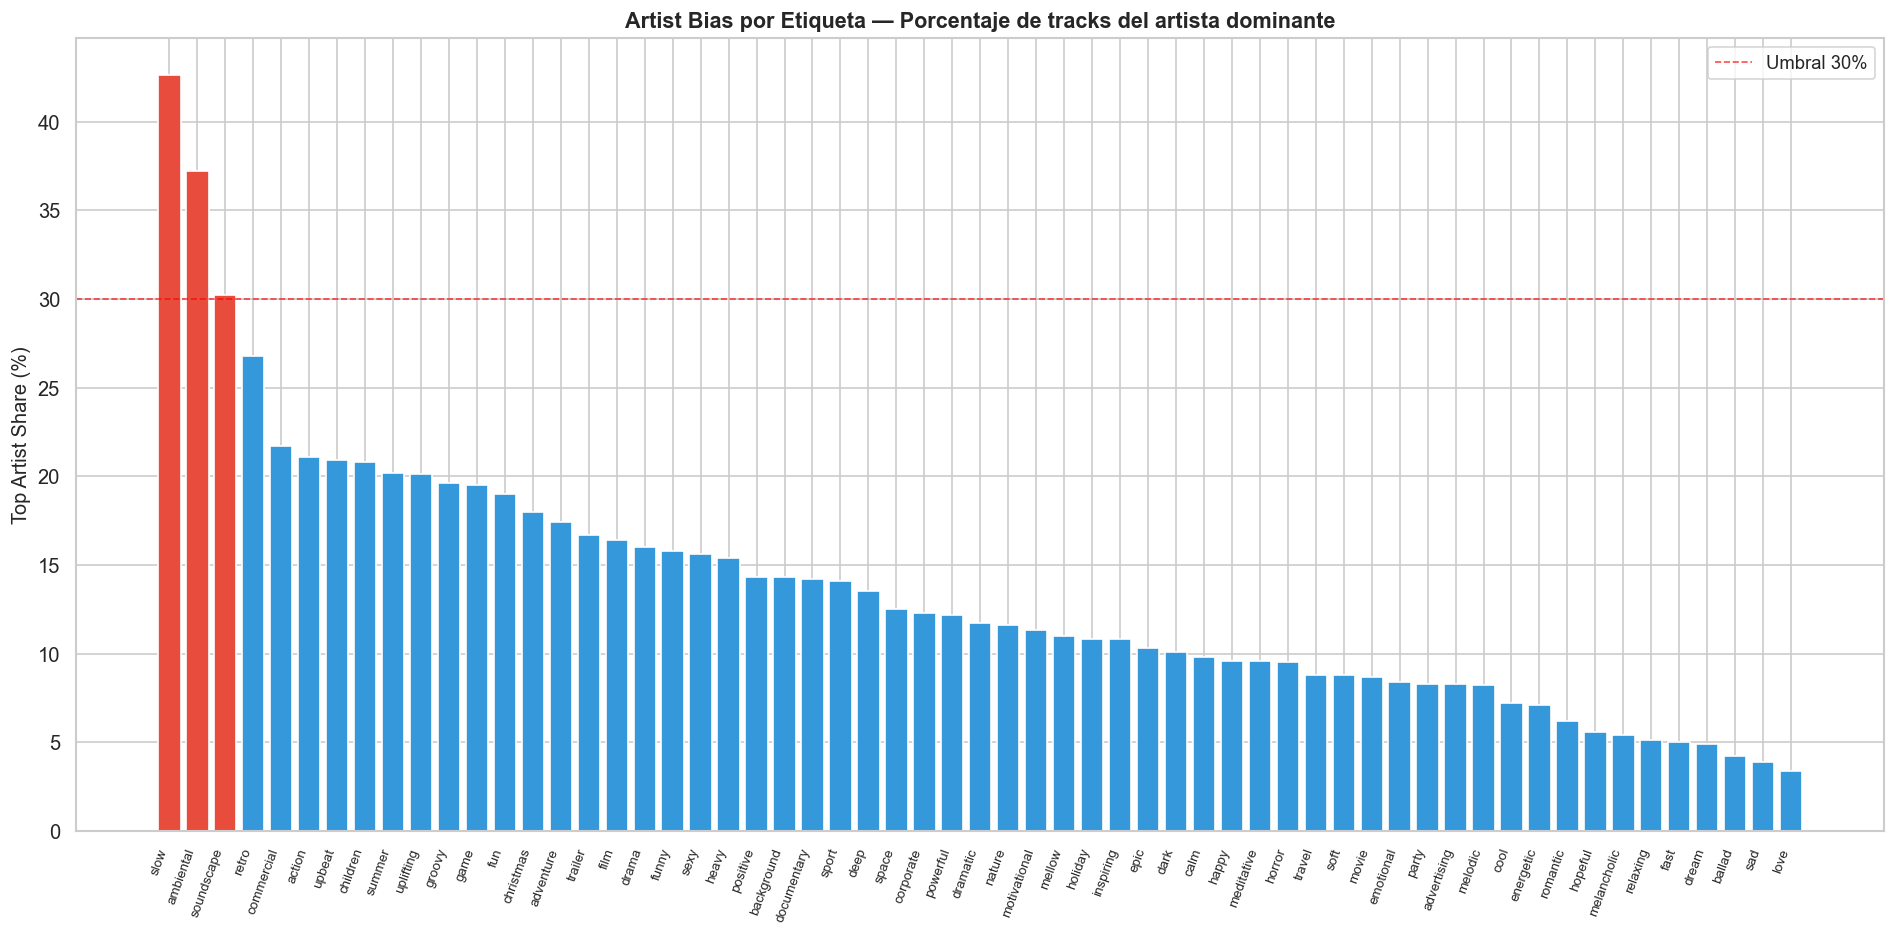

In [36]:
# ── Gráfico de Artist Bias ──
fig, ax = plt.subplots(figsize=(16, 8))

colors = ['#e74c3c' if share >= 30 else '#3498db' for share in bias_df['Top Artist Share %']]
ax.bar(range(len(bias_df)), bias_df['Top Artist Share %'].values, color=colors)

ax.set_xticks(range(len(bias_df)))
ax.set_xticklabels(bias_df['Etiqueta'], rotation=70, ha='right', fontsize=8)
ax.set_ylabel('Top Artist Share (%)', fontsize=12)
ax.set_title('Artist Bias por Etiqueta — Porcentaje de tracks del artista dominante',
             fontsize=13, fontweight='bold')
ax.axhline(30, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Umbral 30%')
ax.legend(fontsize=11)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'artist_bias.png', bbox_inches='tight')
plt.show()

---
## 6 · Prueba de Audio — Descarga y Espectrograma

Descargamos un track de ejemplo desde Jamendo y lo procesamos con `AudioPreprocessor`.

In [ ]:
from audio_utils import AudioPreprocessor

# ── Descargar track de ejemplo desde Jamendo ──
# Usamos la API de descarga: /download/track/{TRACK_ID}/mp32/
JAMENDO_BASE = 'https://prod-1.storage.jamendo.com/download/track/'
track_numeric_id = '1376256'  # corresponde a path 56/1376256.mp3
audio_url = f'{JAMENDO_BASE}{track_numeric_id}/mp32/'
audio_path = DATA_DIR / 'example_track.mp3'

# Headers de navegador para evitar errores 403
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                  'AppleWebKit/537.36 (KHTML, like Gecko) '
                  'Chrome/91.0.4472.124 Safari/537.36'
}

print(f'Track ID: {track_numeric_id}')
print(f'URL: {audio_url}')

if not audio_path.exists():
    print(f'\nDescargando...')
    response = requests.get(audio_url, headers=headers, stream=True, timeout=30)
    response.raise_for_status()
    total = int(response.headers.get('content-length', 0))
    with open(audio_path, 'wb') as f:
        with tqdm(total=total, unit='B', unit_scale=True, desc='Descargando') as pbar:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
                pbar.update(len(chunk))
    print(f'Guardado en: {audio_path}')
else:
    print(f'\nYa descargado: {audio_path}')

print(f'Tamaño: {audio_path.stat().st_size / 1024:.1f} KB')

Track ID: 1376256
URL: https://prod-1.storage.jamendo.com/download/track/1376256/mp32/

✅ Ya descargado: c:\Users\Usuario\OneDrive - UNIVERSIDAD DE MURCIA\Escritorio\CIENCIA DE DATOS RUBEN\CUARTO\TFG_Emociones\data\example_track.mp3
Tamaño: 4032.5 KB


  AudioPreprocessor — Resultado del pipeline
  Waveform shape:      (960000,)   (30.0s @ 32kHz)
  Log-Mel shape:       (128, 3001)   (n_mels × time_frames)
  Tensor final:        [1, 128, 3001]
  Rango dB:            [-80.0, 0.0]
  Waveform rango:      [-1.0000, 0.9950]


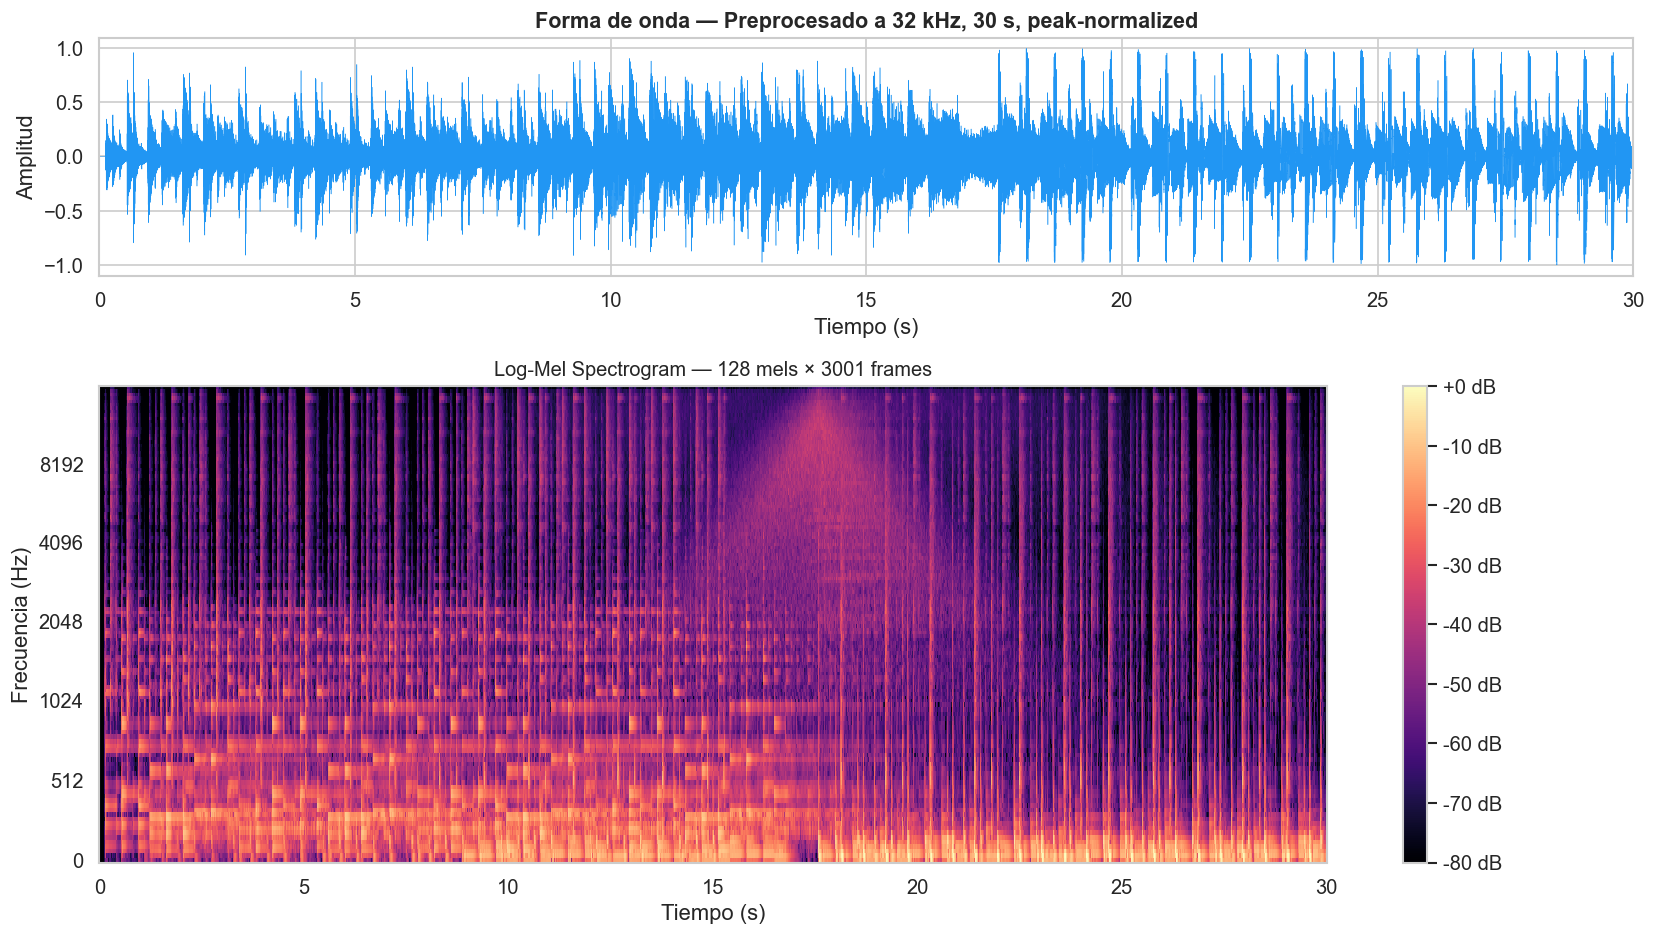


✅ Pipeline de audio verificado correctamente.


In [ ]:
# ── Procesar con AudioPreprocessor ──
preprocessor = AudioPreprocessor(target_sr=32000, duration=30.0)

waveform, log_mel = preprocessor.process(str(audio_path))

print('=' * 55)
print('  AudioPreprocessor — Resultado del pipeline')
print('=' * 55)
print(f'  Waveform shape:      {waveform.shape}   ({waveform.shape[0]/32000:.1f}s @ 32kHz)')
print(f'  Log-Mel shape:       {log_mel.shape}   (n_mels × time_frames)')
print(f'  Tensor final:        [1, {log_mel.shape[0]}, {log_mel.shape[1]}]')
print(f'  Rango dB:            [{log_mel.min():.1f}, {log_mel.max():.1f}]')
print(f'  Waveform rango:      [{waveform.min():.4f}, {waveform.max():.4f}]')
print('=' * 55)

# ── Visualización: Waveform + Log-Mel Spectrogram ──
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [1, 2]})

# Waveform
t = np.linspace(0, 30, len(waveform))
axes[0].plot(t, waveform, linewidth=0.3, color='#2196F3')
axes[0].set_ylabel('Amplitud')
axes[0].set_title(
    f'Forma de onda — Preprocesado a 32 kHz, 30 s, peak-normalized',
    fontsize=13, fontweight='bold'
)
axes[0].set_xlim(0, 30)
axes[0].set_xlabel('Tiempo (s)')

# Log-Mel Spectrogram
import librosa.display
img = librosa.display.specshow(
    log_mel, sr=32000, hop_length=320,
    x_axis='time', y_axis='mel', ax=axes[1]
)
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
axes[1].set_title(
    f'Log-Mel Spectrogram — {log_mel.shape[0]} mels × {log_mel.shape[1]} frames',
    fontsize=12
)
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Frecuencia (Hz)')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'example_spectrogram.png', bbox_inches='tight')
plt.show()

print('\nPipeline de audio verificado correctamente.')

---
## Resumen

| Hallazgo | Detalle |
|---|---|
| **Tracks** | ~18,486 |
| **Etiquetas** | 59 mood/theme |
| **Desbalanceo** | Long-tail significativo |
| **Duración** | ~0% bajo 30 s → operación principal es CROP |
| **Correlación** | Clustermap revela bloques de etiquetas redundantes |
| **Artist Bias** | Etiquetas con ≥30% dominadas por un artista → riesgo de sobreajuste |
| **Audio Pipeline** | Tensor final [1, 128, 3001] — AudioPreprocessor funcional |